In [1]:
#cell 1:

# ==================== 跨平台通用配置（必须放在Cell 1开头） ====================
get_ipython().run_line_magic('matplotlib', 'inline')  # Jupyter必需
import platform
import matplotlib.pyplot as plt

# 降低内存占用（关键！）
plt.rcParams['figure.max_open_warning'] = 20  # 最多同时打开20个图
plt.rcParams['figure.dpi'] = 100  # 降低分辨率减少内存
# 根据操作系统自动选择字体
system = platform.system()
if system == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Heiti SC', 'Arial Unicode MS']
elif system == 'Windows':  # Windows
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Droid Sans Fallback']

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
print(f"✅ 操作系统: {system}")
print(f"✅ 已设置中文字体: {plt.rcParams['font.sans-serif']}")

# ==================== 原有代码 ====================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm
import os

# 设置随机种子（保证可复现）
np.random.seed(42)
torch.manual_seed(42)

# 设备选择（Mac用cpu，如果有MPS可以用mps）
device = torch.device('cpu')
print(f"使用设备: {device}")

# 加载数据（确保文件在同目录下）
df = pd.read_csv('/Users/cherry/Desktop/Orthopedic-Recovery/data/icf/simulated_icf_clinical_data.csv')
print(f"数据加载成功！共 {len(df)} 条记录")
print("\n数据预览：")
print(df.head())
print(f"\n数据形状: {df.shape}")

✅ 操作系统: Darwin
✅ 已设置中文字体: ['Heiti TC', 'Heiti SC', 'Arial Unicode MS']
使用设备: cpu
数据加载成功！共 300 条记录

数据预览：
  patient_id  time_step rehab_phase  icf_total    rom  vas
0       P001          0          早期         56   22.3    6
1       P001          1          早期         71   33.2    5
2       P001          2          中期        111   74.3    8
3       P001          3          中期        119   92.8    5
4       P001          4          中期        137  111.1    4

数据形状: (300, 6)


In [2]:
#cell 2:
# ==================== 构建时序序列 ====================
# 目标：用前N次评估预测下一次的icf_total

def create_sequences(df, n_history=3):
    """
    将数据转换为LSTM需要的序列格式
    
    参数:
        df: 包含patient_id, time_step, icf_total, rom, vas的DataFrame
        n_history: 用前几次预测下一次（默认3次）
    
    返回:
        X: 历史序列 (样本数, 序列长度, 特征数)
        y: 预测目标 (下一个icf_total)
        patient_ids: 用于追踪每个样本属于哪个患者
    """
    sequences = []
    targets = []
    patient_ids = []
    
    # 按患者分组处理
    for pid, group in df.groupby('patient_id'):
        # 按time_step排序（0,1,2,3,4,5）
        group = group.sort_values('time_step')
        
        # 提取数值特征（只用icf_total, rom, vas三个指标）
        features = group[['icf_total', 'rom', 'vas']].values
        
        # 如果数据不足n_history+1次，跳过
        if len(features) <= n_history:
            continue
        
        # 滑动窗口生成序列
        # 例如：用[0,1,2]预测[3]，用[1,2,3]预测[4]，等等
        for i in range(len(features) - n_history):
            seq = features[i:i+n_history]      # 历史3次
            target = features[i+n_history, 0]   # 预测下一次的icf_total（第0列）
            
            sequences.append(seq)
            targets.append(target)
            patient_ids.append(pid)
    
    return np.array(sequences), np.array(targets), patient_ids

# 生成训练数据（用前3次预测第4次）
X, y, pids = create_sequences(df, n_history=3)
print(f"序列数据构建完成！")
print(f"X形状: {X.shape} (样本数={X.shape[0]}, 历史步长={X.shape[1]}, 特征数={X.shape[2]})")
print(f"y形状: {y.shape} (预测icf_total)")
print(f"\n示例：第一个样本")
print(f"历史3次评估:\n{X[0]}")
print(f"预测目标（第4次icf_total）: {y[0]:.2f}")

# 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n训练集: {len(X_train)}个样本")
print(f"测试集: {len(X_test)}个样本")

序列数据构建完成！
X形状: (150, 3, 3) (样本数=150, 历史步长=3, 特征数=3)
y形状: (150,) (预测icf_total)

示例：第一个样本
历史3次评估:
[[ 56.   22.3   6. ]
 [ 71.   33.2   5. ]
 [111.   74.3   8. ]]
预测目标（第4次icf_total）: 119.00

训练集: 120个样本
测试集: 30个样本


In [3]:
#cell 3:
# ==================== 特征标准化（重要！） ====================
# 注意：标准化要在划分后进行，避免数据泄漏

# 重塑为2D进行标准化，再恢复为3D
scaler = StandardScaler()

# 训练集标准化
shape_train = X_train.shape
X_train_2d = X_train.reshape(-1, X_train.shape[-1])  # (样本数*步长, 特征数)
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_train = X_train_2d_scaled.reshape(shape_train)

# 测试集用同样的scaler（只能用transform，不能用fit_transform）
X_test_2d = X_test.reshape(-1, X_test.shape[-1])
X_test_2d_scaled = scaler.transform(X_test_2d)
X_test = X_test_2d_scaled.reshape(X_test.shape)

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # 增加维度
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f"数据标准化完成！")
print(f"训练集X范围: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"训练集y范围: [{y_train.min():.2f}, {y_train.max():.2f}]")

# 在Cell 3末尾添加
print("\n标准化后数据范围检查：")
print(f"X_train ICF列: [{X_train[:,:,0].min():.3f}, {X_train[:,:,0].max():.3f}]")
print(f"y_train: [{y_train.min():.3f}, {y_train.max():.3f}]")

数据标准化完成！
训练集X范围: [-2.32, 2.29]
训练集y范围: [113.00, 200.00]

标准化后数据范围检查：
X_train ICF列: [-1.844, 1.606]
y_train: [113.000, 200.000]


In [4]:
#cell 4:
# ==================== LSTM预测模型 ====================

class ICFPredictorLSTM(nn.Module):
    """
    LSTM多元时序预测模型
    输入: (batch_size, seq_len=3, n_features=3) - 历史3次的icf, rom, vas
    输出: (batch_size, 1) - 预测下一次的icf_total
    """
    def __init__(self, input_size=3, hidden_size=64, num_layers=2):
        super(ICFPredictorLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,      # 3个特征: icf_total, rom, vas
            hidden_size=hidden_size,    # 隐藏层64维
            num_layers=num_layers,      # 2层LSTM
            batch_first=True,           # 批次维度在前
            dropout=0.2                 # 防过拟合
        )
        
        # 全连接输出层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)  # 输出1个预测值（icf_total）
        )
    
    def forward(self, x):
        # LSTM前向传播
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # 取最后一个时间步的输出 (batch, hidden_size)
        last_output = lstm_out[:, -1, :]
        
        # 全连接层预测
        prediction = self.fc(last_output)
        return prediction

# 实例化模型
model = ICFPredictorLSTM(input_size=3, hidden_size=64, num_layers=2).to(device)
print(f"模型结构:\n{model}")
print(f"\n总参数数量: {sum(p.numel() for p in model.parameters()):,}")

模型结构:
ICFPredictorLSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

总参数数量: 53,057


开始训练LSTM模型...


  6%|█████▎                                                                           | 13/200 [00:00<00:01, 121.56it/s]

轮次 [20/200], 平均损失MSE: 14141.2905


 23%|██████████████████▋                                                              | 46/200 [00:00<00:01, 149.58it/s]

轮次 [40/200], 平均损失MSE: 2591.9576


...

轮次 [160/200], 平均损失MSE: 695.1692


 90%|████████████████████████████████████████████████████████████████████████▍       | 181/200 [00:01<00:00, 162.58it/s]

轮次 [180/200], 平均损失MSE: 636.2467


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 157.95it/s]

轮次 [200/200], 平均损失MSE: 554.7399

✅ 训练完成！


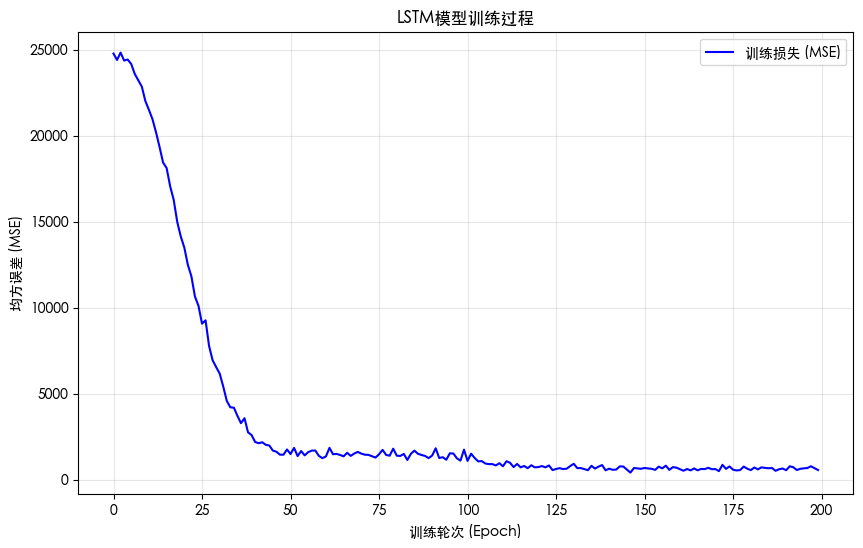


📊 训练效果检查：
最终训练损失: 554.7399
初期训练损失: 24778.4312
损失下降幅度: 97.8%


In [5]:
#cell 5:
# ==================== 模型训练 ====================

# 创建数据加载器（小批量训练）
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差（回归任务）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练循环
num_epochs = 200
train_losses = []

print("开始训练LSTM模型...")
for epoch in tqdm(range(num_epochs)):
    model.train()  # 训练模式
    epoch_losses = []
    
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    # 记录平均损失
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    
    # 每20轮打印一次
    if (epoch + 1) % 20 == 0:
        print(f'轮次 [{epoch+1}/{num_epochs}], 平均损失MSE: {avg_loss:.4f}')

print("\n✅ 训练完成！")

# 绘制训练损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='训练损失 (MSE)', color='blue')
plt.xlabel('训练轮次 (Epoch)')
plt.ylabel('均方误差 (MSE)')
plt.title('LSTM模型训练过程')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 在Cell 5最后添加
print("\n📊 训练效果检查：")
print(f"最终训练损失: {train_losses[-1]:.4f}")
print(f"初期训练损失: {train_losses[0]:.4f}")
print(f"损失下降幅度: {(train_losses[0] - train_losses[-1])/train_losses[0]*100:.1f}%")

# 如果下降幅度<5%，说明模型没学好
if (train_losses[0] - train_losses[-1])/train_losses[0] < 0.05:
    print("⚠️ 警告：损失下降不明显，模型可能欠拟合！")
    print("建议增加训练轮数或调整学习率")

In [6]:
#cell 6:
import os
os.environ['MPLBACKEND'] = 'Agg'  # 完全禁用任何显示

%matplotlib inline
# ==================== 模型评估 ====================
# 预测
model.eval()  # 评估模式
with torch.no_grad():
    y_pred_train = model(X_train_tensor).cpu().numpy()
    y_pred_test = model(X_test_tensor).cpu().numpy()

# 计算MSE和RMSE
mse_train = np.mean((y_train - y_pred_train.flatten())**2)
mse_test = np.mean((y_test - y_pred_test.flatten())**2)
rmse_test = np.sqrt(mse_test)

print(f"📊 模型性能评估：")
print(f"训练集 MSE: {mse_train:.4f}")
print(f"测试集 MSE: {mse_test:.4f}")
print(f"测试集 RMSE: {rmse_test:.4f}")
print(f"测试集平均绝对误差: {np.mean(np.abs(y_test - y_pred_test.flatten())):.4f}")

# ==================== 可视化1：预测值 vs 真实值 ====================
# 保存散点图（不显示）
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=50)
plt.plot([40, 200], [40, 200], 'r--', lw=2,label='完美预测线')
plt.title(f'测试集预测效果\nMSE: {mse_test:.4f} | RMSE: {rmse_test:.4f}', fontsize=14)
plt.xlabel('真实ICF总分', fontsize=12)
plt.ylabel('预测ICF总分', fontsize=12)

# 添加R²分数
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
plt.text(150, 180, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.savefig('scatter_plot.png', dpi=100)
plt.close()  # 必须关闭，否则会内存泄漏
print("✅ 散点图已保存为 scatter_plot.png")


# ==================== 可视化2：时序预测对比（选3个患者） ====================
# 从测试集中找3个患者展示
test_pids = list(set([pids[i] for i in range(len(pids)) if i >= len(X_train)]))[:3]

plt.figure(figsize=(15, 10))
for idx, pid in enumerate(test_pids):
    # 找到该患者的所有数据
    patient_df = df[df['patient_id'] == pid].sort_values('time_step')
    
    # 生成该患者的预测序列（需要重新跑一遍create_sequences逻辑）
    features = patient_df[['icf_total', 'rom', 'vas']].values
    true_icf = patient_df['icf_total'].values
    time_steps = patient_df['time_step'].values
    
    # 用训练好的模型预测（如果有足够历史数据）
    predictions = []
    pred_times = []
    
    for i in range(3, len(features)):  # 从第4个时间点开始预测（需要前3个）
        hist = features[i-3:i]
        hist_scaled = scaler.transform(hist.reshape(-1, 3)).reshape(1, 3, 3)
        hist_tensor = torch.FloatTensor(hist_scaled).to(device)
        
        with torch.no_grad():
            pred = model(hist_tensor).cpu().numpy()[0][0]
        predictions.append(pred)
        pred_times.append(time_steps[i])
    
    # 绘图
    plt.subplot(3, 1, idx+1)
    plt.plot(time_steps, true_icf, 'bo-', label='真实ICF', markersize=8, linewidth=2)
    if predictions:
        plt.plot(pred_times, predictions, 'rx--', label='预测ICF', markersize=8, linewidth=2)
    plt.xlabel('Time Step (评估次数)', fontsize=10)
    plt.ylabel('ICF总分', fontsize=10)
    plt.title(f'患者 {pid} 康复轨迹预测', fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(40, 200)  # 固定Y轴范围
    plt.xticks(time_steps)
    plt.savefig(f'trajectory_{pid}.png', dpi=100)
    plt.close()
    print(f"✅ 轨迹图已保存: trajectory_{pid}.png")


print("\n✅ 所有评估完成！模型已保存为 'icf_lstm_model.pth'")
torch.save(model.state_dict(), 'icf_lstm_model.pth')

📊 模型性能评估：
训练集 MSE: 60.2935
测试集 MSE: 61.3631
测试集 RMSE: 7.8335
测试集平均绝对误差: 6.6488
✅ 散点图已保存为 scatter_plot.png
✅ 轨迹图已保存: trajectory_P041.png
✅ 轨迹图已保存: trajectory_P045.png
✅ 轨迹图已保存: trajectory_P046.png

✅ 所有评估完成！模型已保存为 'icf_lstm_model.pth'
